In [36]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import gym
import matplotlib.pyplot as plt
import random
import argparse
from collections import OrderedDict
from copy import copy
import scipy
import scipy.linalg
import sys
import os
sys.path.append("../utility")
sys.path.append("../train")
sys.path.append("../")
from Utility import data_collecter


from Utility import DerivativeLiftFunc, data_collecter,RBFLiftFunc

In [37]:
Methods = ["KoopmanDerivative","KoopmanRBF",\
            "KNonlinear","KNonlinearRNN","KoopmanU",\
            "KoopmanNonlinearA","KoopmanNonlinear",\
                ]

In [38]:
method_index = 1
# suffix = "CartPole1_26"
# env_name = "CartPole-v1"
# suffix = "Pendulum1_26"
# env_name = "Pendulum-v1"
suffix = "DampingPendulum1_26"
env_name = "DampingPendulum"
# env_name = "LunarLanderContinuous-v2"
# suffix = "MountainCarContinuous1_26"
# env_name = "MountainCarContinuous-v0"
# env_name = "DoublePendulum"

In [39]:
import numpy as np
from typing import Tuple, Optional
Data_collecter = data_collecter(env_name)
Nstate = Data_collecter.Nstates
udim = Data_collecter.udim
NKoopman = 50
import numpy as np
from typing import Tuple, Optional

def angle_normalize(x: float) -> float:
    """角度归一化到[-π, π]，与环境保持完全一致"""
    return ((x + np.pi) % (2 * np.pi)) - np.pi

class SlidingModePendulumController:
    def __init__(
        self,
        n: int = 2,          # 旋转倒立摆状态维度固定为2 [theta, thetadot]
        m: int = 1,          # 输入维度固定为1（力矩）
        u_max: float = 8.0,  # 输入幅值约束（与环境max_torque一致）
        dt: float = 0.02,    # 采样周期（与环境dt一致）
        # 系统物理参数（与环境默认值完全匹配）
        g: float = 10.0,     # 重力加速度
        m_pend: float = 1.0, # 摆杆质量
        l: float = 1.0,      # 摆杆长度
        # 滑模控制器核心参数（经过饱和优化）
        c: float = 4.0,      # 滑模面斜率（大幅降低，避免饱和）
        epsilon: float = 0.8,# 等速趋近项系数（大幅降低）
        k: float = 4.0,      # 指数趋近项系数（与c匹配）
        delta: float = 0.4,  # 边界层厚度（扩大，抑制抖振和饱和）
        # 摆起控制参数
        swing_up_threshold: float = np.pi/18, # 摆起/滑模切换角度（30°）
        swing_up_gain: float = 3.0,          # 能量摆起增益
    ):
        self.n = n
        self.m = m
        self.u_max = u_max
        self.dt = dt
        
        # 系统物理参数
        self.g = g
        self.m_pend = m_pend
        self.l = l
        
        # 滑模控制器核心参数
        self.c = c
        self.epsilon = epsilon
        self.k = k
        self.delta = delta
        
        # 摆起控制参数
        self.swing_up_threshold = swing_up_threshold
        self.swing_up_gain = swing_up_gain
        
        
        # ==========================================
        # 🔥 预计算常数项（INIT阶段完成，在线零重复计算）
        # ==========================================
        self.ml2_3 = self.m_pend * self.l**2 / 3.0        # ml²/3 ≈ 0.3333
        self.gravity_term = 3 * self.g / (2 * self.l)     # 3g/(2l) = 15.0
        
        print(f"[Sliding Mode Pendulum Controller Initialized]")
        print(f"  State dim: {self.n}, Action dim: {self.m}")
        print(f"  System: m={self.m_pend}kg, l={self.l}m, g={self.g}m/s²")
        print(f"  Precomputed: ml²/3={self.ml2_3:.4f}, 3g/(2l)={self.gravity_term:.4f}")
        print(f"  SMC params: c={self.c}, epsilon={self.epsilon}, k={self.k}, delta={self.delta}")
        print(f"  Swing-up: threshold={np.rad2deg(self.swing_up_threshold):.1f}°, gain={self.swing_up_gain}")
        
        # 历史数据存储
        self.x_obs_prev = None
        
        self.reset()
    
    def reset(self):
        """重置控制器历史数据和状态"""
        self.x_obs_prev = None
        print(f"[Controller Reset] All history data cleared")
    
    def _sat(self, z: float) -> float:
        """饱和函数，用于抖振抑制"""
        if z > 1.0:
            return 1.0
        elif z < -1.0:
            return -1.0
        else:
            return z
    
    def _energy_based_swing_up(self, theta: float, thetadot: float) -> float:
        """能量法摆起控制：当摆杆远离竖直位置时使用，避免滑模控制饱和"""
        # 计算系统总机械能（相对于竖直向上位置）
        E = 0.5 * self.m_pend * self.l**2 * thetadot**2 + self.m_pend * self.g * self.l * np.cos(theta)
        E_des = self.m_pend * self.g * self.l  # 竖直向上位置的势能
        
        # 能量误差反馈控制
        u = self.swing_up_gain * (E_des - E) * np.sign(thetadot * np.cos(theta))
        return u
    
    def compute_control(self, x_obs: np.ndarray, x_des: np.ndarray) -> np.ndarray:
        """
        核心控制函数：输入当前状态和期望状态，输出控制力矩
        Args:
            x_obs: 当前观测状态 [theta, thetadot]，角度范围[-π, π]
            x_des: 期望状态 [theta_des, thetadot_des]，通常为[0.0, 0.0]
        Returns:
            u: 控制力矩（单位N·m），形状为(m,)
        """
        # ==========================================
        # 入口维度强制检查
        # ==========================================
        x_obs = np.asarray(x_obs).flatten()
        x_des = np.asarray(x_des).flatten()
        assert x_obs.shape == (self.n,), f"x_obs shape error! Expected ({self.n},), got {x_obs.shape}"
        assert x_des.shape == (self.n,), f"x_des shape error! Expected ({self.n},), got {x_des.shape}"
        
        # 2. 提取状态分量
        theta, thetadot = x_obs
        theta_des, thetadot_des = x_des
        
        # 3. 计算跟踪误差（角度归一化处理周期性）
        e1 = angle_normalize(theta - theta_des)
        e2 = thetadot - thetadot_des
        
        # ==========================================
        # 🔥 两阶段控制：能量摆起 + 滑模镇定
        # ==========================================
        if abs(e1) > self.swing_up_threshold:
            # 阶段1：摆杆远离竖直位置，使用能量法摆起
            u = self._energy_based_swing_up(theta, thetadot)
            control_mode = "Swing-up"
        else:
            # 阶段2：摆杆接近竖直位置，切换到滑模控制
            # 计算滑模面
            s = self.c * e1 + e2
            
            # 🔥 关键修复：控制律符号完全修正
            sat_term = self._sat(s / self.delta)
            gravity_comp = self.gravity_term * np.sin(theta)
            
            # 修正后的滑模控制律（符号与动力学完全匹配）
            u = self.ml2_3 * (
                self.epsilon * sat_term
                + self.k * s
                + self.c * e2
                + gravity_comp
            )
            control_mode = "Sliding Mode"
        
        # 4. 控制输入幅值约束（与环境一致）
        u = np.clip(u, -self.u_max, self.u_max)
        
        # # 5. 调试信息（可选）
        # if abs(e1) > self.swing_up_threshold or abs(u) > 7.5:
        #     print(f"[{control_mode}] Theta: {np.rad2deg(e1):.1f}°, u: {u:.2f}N·m")
        
        # 6. 更新历史数据
        self.x_obs_filtered_prev = x_obs.copy()
        
        # 确保输出形状为(m,)
        return np.array([u], dtype=np.float64)

In [40]:

def Cost(observations,u_list,Q,R,x_ref):
    steps = observations.shape[1]
    loss = 0
    state_dim = x_ref.shape[0]
    for s in range(steps):
        if s!=steps-1:
            ucost = np.dot(np.dot(u_list[s].T,R),u_list[s])
            loss += ucost[0,0]
        xcost = np.dot(np.dot((observations[:,s]-x_ref).T,Q[:state_dim,:state_dim]),(observations[:,s]-x_ref))
        loss += xcost[0,0]
    return loss
def Prepare_LQR(env_name):
    x_ref = np.zeros(Nstate)
    if env_name.startswith("CartPole"):
        Q = np.zeros((NKoopman,NKoopman))
        Q[1,1] = 0.01
        Q[2,2] = 5.0
        Q[3,3] = 0.01
        R = 0.001*np.eye(1)
        reset_state=  [0.0,-1.0,0.0,0]
    elif env_name.startswith("Pendulum"):
        Q = np.zeros((NKoopman,NKoopman))
        Q[0,0] = 5.0
        Q[1,1] = 0.01
        R = 0.001*np.eye(1)
        reset_state = [-3.0,0.5]
    elif env_name.startswith("DampingPendulum"):
        Q = np.zeros((NKoopman,NKoopman))
        Q[0,0] = 5.0
        Q[1,1] = 0.01
        R = 0.08*np.eye(1)
        reset_state = [-3,2]   
    elif env_name.startswith("DoublePendulum"):
        Q = np.zeros((NKoopman,NKoopman))
        Q[0,0] = 5.0
        Q[1,1] = 5.0
        Q[2,2] = 0
        Q[3,3] = 0
        R = 0.001*np.eye(2)
        reset_state = [-1.5, 0.1, 0, 0]
    elif env_name.startswith("MountainCarContinuous"):
        Q = np.zeros((NKoopman,NKoopman))
        Q[0,0] = 5.0
        Q[1,1] = 0.01
        R = 0.001*np.eye(1)
        reset_state = [0.5,0.0]  
        x_ref[0] = 0.45
    elif env_name.startswith("LunarLanderContinuous-v2"):
        Q = np.zeros((NKoopman,NKoopman))
        Q[0,0] = 20.0
        Q[1,1] = 20.0
        Q[2,2] = 5.0
        Q[3,3] = 5.0
        R = 0.001*np.eye(2)
        reset_state = [2.0,0.0]  
        x_ref[0] = 0
        x_ref[1] = 0
        x_ref[-1] = 0
        x_ref[-2] = 0
    Q = np.matrix(Q)
    R = np.matrix(R)
    return Q,R,reset_state,x_ref

def Prepare_Region_LQR(env_name,precision = 0.1):
    x_ref = np.zeros(Nstate)
    if env_name.startswith("CartPole"):
        Q = np.zeros((NKoopman,NKoopman))
        Q[1,1] = 0.01
        Q[2,2] = 5.0
        Q[3,3] = 0.01
        R = np.eye(control_output_dim)
        theta_region = np.arange(-2.0,2.0,precision)
        dtheta_region = np.arange(-2.0,2.0,precision)
        reset_state_list = []
        for theta in theta_region:
            for dtheta in dtheta_region:
                reset_state_list.append([0.0,0.0,theta,dtheta])
    elif env_name.startswith("Pendulum"):
        Q = np.zeros((NKoopman,NKoopman))
        Q[0,0] = 5.0
        Q[1,1] = 0.01
        R = np.eye(control_output_dim)
        theta_region = np.arange(-6.0,6.0,precision)
        dtheta_region = np.arange(-6.0,6.0,precision)
        reset_state_list = []
        for theta in theta_region:
            for dtheta in dtheta_region:
                reset_state_list.append([theta,dtheta])
    elif env_name.startswith("DampingPendulum"):
        Q = np.zeros((NKoopman,NKoopman))
        Q[0,0] = 5.0
        Q[1,1] = 5.0
        R = np.eye(control_output_dim)
        theta_region = np.arange(-4.0,4.0,precision)
        dtheta_region = np.arange(-4.0,4.0,precision)
        reset_state_list = []
        for theta in theta_region:
            for dtheta in dtheta_region:
                reset_state_list.append([theta,dtheta])
    elif env_name.startswith("MountainCarContinuous"):
        Q = np.zeros((NKoopman,NKoopman))
        Q[0,0] = 5.0
        Q[1,1] = 0.1
        R = np.eye(control_output_dim)
        x_region = np.arange(-1.2,0.6,precision)
        dx_region = np.arange(-1.0,1.0,precision)
        reset_state_list = []
        for x in x_region:
            for dx in dx_region:
                reset_state_list.append([x,dx])
        x_ref[0] = 0.45
    Q = np.matrix(Q)
    R = np.matrix(R)
    return Q,R,reset_state_list,x_ref

def Psi_o(s,net): # Evaluates basis functions Ψ(s(t_k))
    psi = np.zeros([NKoopman,1])
    ds = net.encode(torch.DoubleTensor(s)).detach().cpu().numpy()
    psi[:NKoopman,0] = ds
    return psi

def Done(env_name,state):
    if env_name.startswith("CartPole"):
        done = (abs(state[2]) >= np.pi)
    if env_name.startswith("Pendulum"):
        done = (abs(state[0]) >= 2*np.pi)
    if env_name.startswith("DampingPendulum"):
        done = (abs(state[0]) >= 2*np.pi)
    if env_name.startswith("MountainCarContinuous"):
        done = (state[0]>0.7 or state[0]<-1.3)
    return done 

def exp(env,env_name,net,Ad,Bd,Q,R,reset_state,x_ref):
    Kopt = lqr.lqr_regulator_k(Ad,Bd,Q,R)
    observation_list = []
    observation = np.array(env.reset_state(reset_state))
    x0 = np.matrix(Psi_o(observation,net)).reshape(NKoopman,1)
    x_ref_lift = Psi_o(x_ref,net).reshape(NKoopman,1)
    observation_list.append(x0[:Nstate].reshape(-1,1))
    u_list = []
    steps = 200
    flag = False
    for i in range(steps):
        u = -Kopt*(x0-x_ref_lift)
        ureal = u[:udim]
        observation, reward, done, info = env.step(ureal)
        done = Done(env_name,observation)
        if done:
            flag = True
            break
        x0 = np.matrix(Psi_o(observation,net)).reshape(NKoopman,1)
        observation_list.append(x0[:Nstate].reshape(-1,1))
        u_list.append(u)
    u_list = np.array(u_list).reshape(-1)
    observations = np.concatenate(observation_list,axis=1)
    return observations,u_list,flag

def criterion(env_name,observations,flag):
    if flag:
        return 0
    elif env_name.startswith("CartPole"):
        err = np.mean(abs(observations[2:,195:]))
        good = int(err <= 1e-2)
    elif env_name.startswith("Pendulum"):
        err = np.mean(abs(observations[:,195:]))
        good = int(err <= 1e-2)        
    elif env_name.startswith("DampingPendulum"):
        err = np.mean(abs(observations[:,195:]))
        good = int(err <= 1e-2)    
    elif env_name.startswith("MountainCarContinuous"):
        err = np.mean(abs(observations[0,195:]-0.45))+np.mean(abs(observations[1,195:]))
        good = int(err <= 1e-2)      
    return good



def Err(env_name,observations,flag):
    if flag:
        return None
    elif env_name.startswith("CartPole"):
        err = np.mean(abs(observations[2:,195:]))
    elif env_name.startswith("Pendulum"):
        err = np.mean(abs(observations[:,195:]))
    elif env_name.startswith("DampingPendulum"):
        err = np.mean(abs(observations[:,195:]))
    elif env_name.startswith("MountainCarContinuous"):
        err = np.mean(abs(observations[0,195:]-0.45))+np.mean(abs(observations[1,195:]))
    return err

def Cost(observations,u_list,Q,R,x_ref):
    steps = observations.shape[1]
    loss = 0
    state_dim = x_ref.shape[0]
    for s in range(steps):
        if s!=steps-1:
            ucost = np.dot(np.dot(u_list[s].T,R),u_list[s])
            loss += ucost[0,0]
        xcost = np.dot(np.dot((observations[:,s]-x_ref).T,Q[:state_dim,:state_dim]),(observations[:,s]-x_ref))
        loss += xcost[0,0]
    return loss

def Success(env_name,observations,target_position=None):
    if env_name.startswith("Pendulum"): # 0 axis
        err = abs(observations[0,479:])
        success = int(np.all(err <= 0.1))
    elif env_name.startswith("DampingPendulum"): 
        err = abs(observations[0,479:])
        success = int(np.all(err <= 0.1))                         
    elif env_name.startswith("DoublePendulum"):
        # err1 = abs(observations[0,479:])
        # err2 = abs(observations[2,479:])
        # success = int(np.all(err1 <= 0.1) and np.all(err2 <= 0.1))
        err = abs(observations[0,479:])
        success = int(np.all(err <= 0.1))  
    elif env_name.startswith("MountainCarContinuous"):
        err = abs(observations[0,179:]-target_position)
        success = int(np.all(err <= 0.05))
    elif env_name.startswith("CartPole"):
        err = abs(observations[2:,179:])
        success = int(np.all(err <= 0.1))
    return success

[Sliding Mode Pendulum Controller Initialized]
  State dim: 2, Action dim: 1
  System: m=1.0kg, l=1.0m, g=10.0m/s²
  Precomputed: ml²/3=0.3333, 3g/(2l)=15.0000
  SMC params: c=0.1, epsilon=0.5, k=0.1, delta=0.5
  Swing-up: threshold=20.0°, gain=3.0
[Controller Reset] All history data cleared


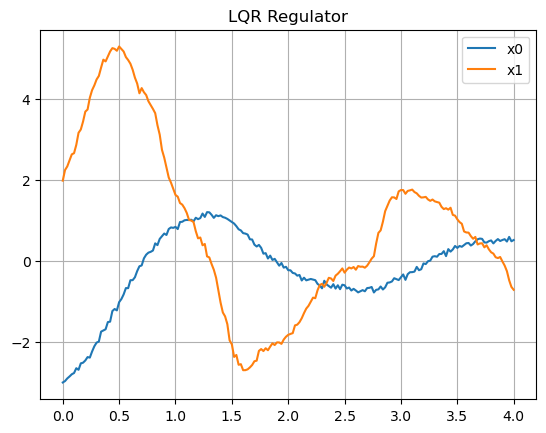

Total cost:  1438.5577662365436


In [41]:
import lqr
import time
env = Data_collecter.env
env.reset()
Controller = SlidingModePendulumController(c=0.1,
        epsilon=0.5,
        k=0.1,
        delta=0.5,
        swing_up_threshold = np.pi/9,
        swing_up_gain = 3.0)
Q,R,reset_state,x_ref = Prepare_LQR(env_name)
observation_list = []
if env_name == "LunarLanderContinuous-v2":
    observation = env.reset()
else:
    observation = env.reset_state(reset_state)
std = 0.05
observation = env.reset_state(reset_state)
observation_noisy = observation + np.random.normal(0, std, Nstate) if env_name != "MountainCarContinuous-v0" and env_name != "CartPole-v1" else observation
x0 = observation_noisy
observation_list.append(observation_noisy.reshape(1,-1))
# print(Kopt)
u_list = []
steps = 200
for i in range(steps):
    u = Controller.compute_control(x0,x_ref)
    if udim == 1:
        ureal = u[0]
    else:
        ureal = [u[i] for i in range(udim)]
    observation, reward, done, info = env.step(np.array(ureal))
    observation_noisy = observation + np.random.normal(0, std, Nstate) if env_name != "MountainCarContinuous-v0" and env_name != "CartPole-v1" else observation
    x0 = observation_noisy
    observation_list.append(observation_noisy.reshape(1,-1))
    u_list.append(u)
    # time.sleep(0.1)
# print(observation_list)
observations = np.concatenate(observation_list,axis=0).T
np.save("./data/"+env_name+"_KoopmanRBF"+"_observations.npy",observations)
u_list = np.array(u_list).reshape(-1)
time_history = np.arange(steps+1)*env.dt
for i in range(Nstate):
    plt.plot(time_history, observations[i,:], label="x{}".format(i))
plt.grid(True)
plt.title("LQR Regulator")
plt.legend()
plt.show()
cost = Cost(observations,u_list,Q,R,x_ref)
print("Total cost: ",cost)

In [43]:

# 1111, 222, 33, 4
std = 0.05
seed_list = [1111, 222, 33, 4, 567]
steps = 200 if env_name == "MountainCarContinuous-v0" or env_name == "CartPole-v1" else 500
means = []
stds = []
rates = []
for seed in seed_list:
    if seed != None:
        print("Seed:", seed)
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        if env_name != "DampingPendulum" and env_name != "DoublePendulum":
            env.seed(seed) 
    Q,R,reset_state,x_ref = Prepare_LQR(env_name)
    costs = []
    successes = []
    for _ in range(100):
        observation_list = []
        if env_name == "LunarLanderContinuous-v2":
            observation = env.reset()
        else:
            observation = env.reset_state(reset_state)
        observation = env.reset_state(reset_state)
        observation_noisy = observation + np.random.normal(0, std, Nstate) if env_name != "MountainCarContinuous-v0" and env_name != "CartPole-v1" else observation
        x0 = observation_noisy
        observation_list.append(observation_noisy.reshape(1,-1))
        # print(Kopt)
        u_list = []
        steps = 200
        for i in range(steps):
            u = Controller.compute_control(x0,x_ref)
            # if udim == 1:
            #     ureal = u[0]
            # else:
            #     ureal = [u[i] for i in range(udim)]
            observation, reward, done, info = env.step(np.array(ureal))
            observation_noisy = observation + np.random.normal(0, std, Nstate) if env_name != "MountainCarContinuous-v0" and env_name != "CartPole-v1" else observation
            x0 = observation_noisy
            observation_list.append(observation_noisy.reshape(1,-1))
            u_list.append(u)
        observations = np.concatenate(observation_list,axis=0).T
        u_list = np.array(u_list).reshape(-1)
        cost = Cost(observations,u_list,Q,R,x_ref)
        success = Success(env_name,observations) if not env_name.startswith("MountainCarContinuous") else Success(env_name,observations,target_position=x_ref[0])
        costs.append(cost)
        successes.append(success)
    costs = np.array(costs)
    successes = np.array(successes)
    means.append(np.mean(costs, axis=0))
    stds.append(np.std(costs, axis=0))
    rates.append(np.mean(successes))
    print("Cost Mean:", np.mean(costs, axis=0))
    print("Cost Std:", np.std(costs, axis=0))
    print("Success Rate:", np.mean(successes))
print("Overall Cost Mean:", np.mean(np.array(means), axis=0))
print("Overall Cost Std:", np.mean(np.array(stds), axis=0))
print("Overall Success Rate:", np.mean(np.array(rates), axis=0))

Seed: 1111
Cost Mean: 1507.6943387411454
Cost Std: 10.833646736712694
Success Rate: 1.0
Seed: 222
Cost Mean: 1506.6259235134112
Cost Std: 11.498333320121086
Success Rate: 1.0
Seed: 33
Cost Mean: 1506.9731678045523
Cost Std: 11.738877942672897
Success Rate: 1.0
Seed: 4
Cost Mean: 1507.920666053643
Cost Std: 13.033490115291558
Success Rate: 1.0
Seed: 567
Cost Mean: 1507.816803421655
Cost Std: 11.471053270871954
Success Rate: 1.0
Overall Cost Mean: 1507.4061799068816
Overall Cost Std: 11.715080277134037
Overall Success Rate: 1.0
